### Preprocess

In [1]:
import sys
sys.path.append("ee467-final")

import importlib
import preprocessing
importlib.reload(preprocessing)
from imblearn.over_sampling import SMOTE


from preprocessing import preprocess
from models import baseline, svm_model, decision_tree, random_forest, gradient_boost
from evaluation import evaluate_model_base, plot_recall
from feature_engineering import reduce_dim, visualize_samples

Series([], dtype: int64)
SMOTE
SMOTE + PCA
Original shape: (875512, 78)
Explained variance ratio: [0.93980697 0.02088603]
Cumulative variance: [0.93980697 0.960693  ]
Reduced shape: (875512, 2)
manual
Original shape: (181752, 78)
Dropping cols with high corr: ['log_data-ranges_max', 'log_data-ranges_min', 'network_fragmented-packets', 'network_header-length_max', 'network_header-length_min', 'network_ip-length_max', 'network_ip-length_min', 'network_ips_dst_count', 'network_ips_src_count', 'network_macs_all_count', 'network_macs_dst_count', 'network_macs_src_count', 'network_mss_max', 'network_mss_min', 'network_packet-size_max', 'network_packet-size_min', 'network_packet-size_std_deviation', 'network_packets_dst_count', 'network_payload-length_std_deviation', 'network_ports_src_count', 'network_tcp-flags_max', 'network_ttl_avg', 'network_ttl_max', 'network_ttl_min', 'network_window-size_avg', 'network_window-size_max', 'network_window-size_std_deviation', 'fragmentation', 'packet_rate

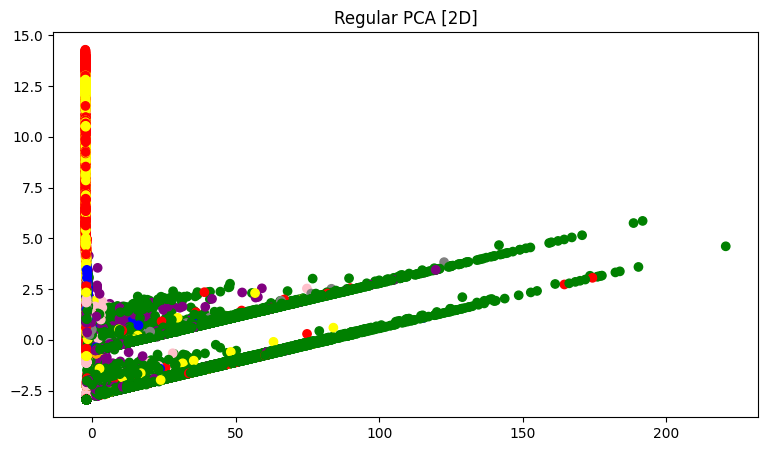

In [2]:
# preprocessing dataset
x_train, x_test, y_train, y_test = preprocess()

# add SMOTE
print("SMOTE")
smote_instance = SMOTE(random_state=67)
x_train_smote, y_train_smote = smote_instance.fit_resample(x_train, y_train)

#smote + dim
print("SMOTE + PCA")
x_train_sm, x_test_sm = reduce_dim(x_train_smote, x_test, mode="PCA")

#dim reduction
print("manual")
x_train_m, x_test_m = reduce_dim(x_train, x_test, mode="manual")

print("PCA w/ standard scaling")
x_train_s, x_test_s = reduce_dim(x_train, x_test, mode="PCA", standard=True)

#dim reduction
print("PCA")
x_train, x_test = reduce_dim(x_train, x_test, mode="PCA")
visualize_samples(x_train, y_train, title="Regular PCA")


In [3]:

# train models: baseline_logistiregression, svm, random_forest, gradient_boost, decision tree, bagging tree
baseline_model = baseline(x_train, y_train)
_,_,_,_, fpr_b, tpr_b = evaluate_model_base(baseline_model, x_test, y_test)

Accuracy: 0.65
Precision: 0.43
Recall: 0.47
F1: 0.42

Confusion Matrix
[[21294   684   108     0    55  4601   439   180]
 [   87    43     0     0    32   122    67    23]
 [  351    57   734  1546   182   397   256    88]
 [  225    58  1000  1638   179   295   195    94]
 [  103    34    37     0   863   295   142    34]
 [  477    27     9     1   231   813     3    51]
 [ 1670   198    13    17   707   306  3732    87]
 [   69    12     0     0     4   113    11   350]]

Classification Report
              precision    recall  f1-score   support

      benign       0.88      0.78      0.82     27361
  bruteforce       0.04      0.11      0.06       374
        ddos       0.39      0.20      0.27      3611
         dos       0.51      0.44      0.48      3684
     malware       0.38      0.57      0.46      1508
        mitm       0.12      0.50      0.19      1612
       recon       0.77      0.55      0.64      6730
         web       0.39      0.63      0.48       559

    accur

In [4]:
dt_model = decision_tree(x_train, y_train)
_,_,_,_, fpr_dt, tpr_dt = evaluate_model_base(dt_model, x_test, y_test)

Accuracy: 0.74
Precision: 0.59
Recall: 0.67
F1: 0.57

Confusion Matrix
[[22290  1959    13     1   182  1320   533  1063]
 [   85   235     1     0     5     2     5    41]
 [  345   114  2310   608    42    60    27   105]
 [  216   110   335  2838     9   137     8    31]
 [  134   207     5    27   891    23    33   188]
 [  200   393    11    25    20   880     5    78]
 [ 1693   812    19    63   122   138  3630   253]
 [   60    30     1     0     1     8     5   454]]

Classification Report
              precision    recall  f1-score   support

      benign       0.89      0.81      0.85     27361
  bruteforce       0.06      0.63      0.11       374
        ddos       0.86      0.64      0.73      3611
         dos       0.80      0.77      0.78      3684
     malware       0.70      0.59      0.64      1508
        mitm       0.34      0.55      0.42      1612
       recon       0.85      0.54      0.66      6730
         web       0.21      0.81      0.33       559

    accur

In [5]:
rf_model = random_forest(x_train, y_train)
_,_,_,_, fpr_rf, tpr_rf = evaluate_model_base(rf_model, x_test, y_test)

Accuracy: 0.85
Precision: 0.72
Recall: 0.78
F1: 0.73

Confusion Matrix
[[24955   444    40    23   381  1123   296    99]
 [   87   196     0     0    16    55    10    10]
 [  380    22  2898   186    34    63    17    11]
 [  231    34   152  3134    24    77    16    16]
 [  138    58     8     0  1209    74    16     5]
 [  188    95    13    11    37  1260     7     1]
 [ 1657    96    21     9   155    81  4671    40]
 [   60    18     0     0     4     2     0   475]]

Classification Report
              precision    recall  f1-score   support

      benign       0.90      0.91      0.91     27361
  bruteforce       0.20      0.52      0.29       374
        ddos       0.93      0.80      0.86      3611
         dos       0.93      0.85      0.89      3684
     malware       0.65      0.80      0.72      1508
        mitm       0.46      0.78      0.58      1612
       recon       0.93      0.69      0.79      6730
         web       0.72      0.85      0.78       559

    accur

Accuracy: 0.90
Precision: 0.82
Recall: 0.85
F1: 0.82

Confusion Matrix
[[26019   660    14    24   171   281   167    25]
 [   79   276     0     0    13     5     0     1]
 [  340    28  3049   118    11    42    18     5]
 [  212    13    13  3346    12    78     9     1]
 [  120    87     1     0  1281    15     4     0]
 [  131    16     4     2     9  1446     4     0]
 [ 1441    34     0     7    63   100  5083     2]
 [   58    16     0     0     0     0     0   485]]

Classification Report
              precision    recall  f1-score   support

      benign       0.92      0.95      0.93     27361
  bruteforce       0.24      0.74      0.37       374
        ddos       0.99      0.84      0.91      3611
         dos       0.96      0.91      0.93      3684
     malware       0.82      0.85      0.84      1508
        mitm       0.74      0.90      0.81      1612
       recon       0.96      0.76      0.85      6730
         web       0.93      0.87      0.90       559

    accur

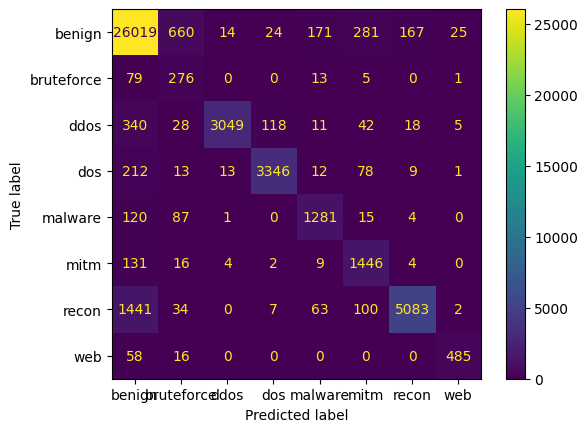

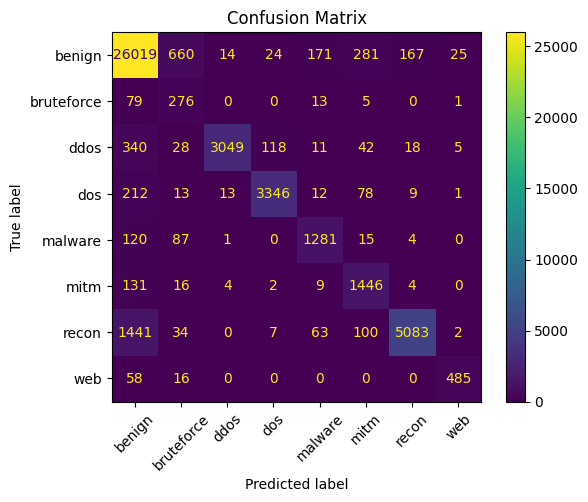

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,  confusion_matrix
import matplotlib.pyplot as plt
## manual feature reduction
rf_m_model = random_forest(x_train_m, y_train)
y_pred = rf_m_model.predict(x_test_m)
cm = confusion_matrix(y_test, y_pred)

_,_,_,_, fpr_rf_m, tpr_rf_m = evaluate_model_base(rf_m_model, x_test_m, y_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_m_model.classes_)
disp.plot()
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [7]:
# standard scaling
rf_s_model = random_forest(x_train_s, y_train)
_,_,_,_, fpr_rf_s, tpr_rf_s = evaluate_model_base(rf_s_model, x_test_s, y_test)

Accuracy: 0.87
Precision: 0.75
Recall: 0.80
F1: 0.76

Confusion Matrix
[[25398   473    23    31   312   716   317    91]
 [   84   211     0     0    17    56     1     5]
 [  363    18  2998   125    13    66    11    17]
 [  227    22    75  3228    24    80    21     7]
 [  126    56     3     6  1254    45    14     4]
 [  172    81    10     2    25  1310    12     0]
 [ 1604    42     4     2   122    87  4845    24]
 [   60     6     0     0     4     1     0   488]]

Classification Report
              precision    recall  f1-score   support

      benign       0.91      0.93      0.92     27361
  bruteforce       0.23      0.56      0.33       374
        ddos       0.96      0.83      0.89      3611
         dos       0.95      0.88      0.91      3684
     malware       0.71      0.83      0.76      1508
        mitm       0.55      0.81      0.66      1612
       recon       0.93      0.72      0.81      6730
         web       0.77      0.87      0.82       559

    accur

In [8]:
# smote
rf_sm_model = random_forest(x_train_sm, y_train_smote)
_,_,_,_, fpr_rf_sm, tpr_rf_sm = evaluate_model_base(rf_sm_model, x_test_sm, y_test)

Accuracy: 0.80
Precision: 0.61
Recall: 0.68
F1: 0.63

Confusion Matrix
[[23955   958    81    20   633   543   961   210]
 [   89   153     2     0    62    46     9    13]
 [  349    75  2780   215    63    65    49    15]
 [  219    36   266  2993    35    82    33    20]
 [  127   137    35     8   962    37   148    54]
 [  177   203    21    20    80  1032    64    15]
 [ 1683   223    73    12   484   167  3942   146]
 [   67    18     3     1    26    11    15   418]]

Classification Report
              precision    recall  f1-score   support

      benign       0.90      0.88      0.89     27361
  bruteforce       0.08      0.41      0.14       374
        ddos       0.85      0.77      0.81      3611
         dos       0.92      0.81      0.86      3684
     malware       0.41      0.64      0.50      1508
        mitm       0.52      0.64      0.57      1612
       recon       0.76      0.59      0.66      6730
         web       0.47      0.75      0.58       559

    accur

In [9]:
gd_model = gradient_boost(x_train, y_train)
_,_,_,_, fpr_gb, tpr_gb = evaluate_model_base(gd_model, x_test, y_test)

Accuracy: 0.87
Precision: 0.85
Recall: 0.66
F1: 0.72

Confusion Matrix
[[27197    14     7     0    47    44    41    11]
 [  204    63     0     0    29    12    64     2]
 [  580     0  2589   345    12    24    57     4]
 [  304     1   209  3042     8    71    44     5]
 [  351     6    29     4   991    21   103     3]
 [  757     1    22    32    16   776     8     0]
 [ 2151    17    32     7    54    13  4447     9]
 [  110     1     3     0     2     1    24   418]]

Classification Report
              precision    recall  f1-score   support

      benign       0.86      0.99      0.92     27361
  bruteforce       0.61      0.17      0.26       374
        ddos       0.90      0.72      0.80      3611
         dos       0.89      0.83      0.86      3684
     malware       0.86      0.66      0.74      1508
        mitm       0.81      0.48      0.60      1612
       recon       0.93      0.66      0.77      6730
         web       0.92      0.75      0.83       559

    accur

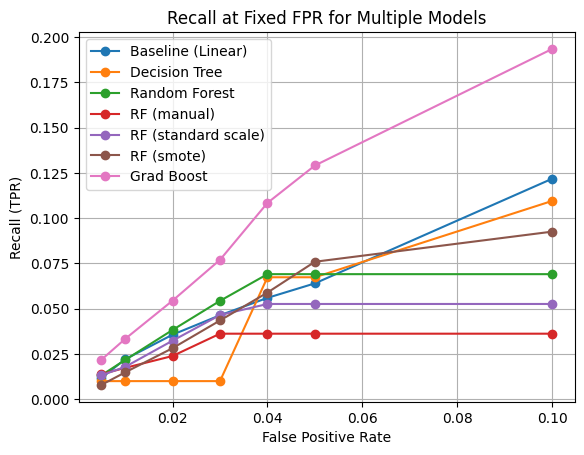

In [14]:
import numpy as np
import matplotlib.pyplot as plt 


def plot_recall(models):
  fprs = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.1]

  def recall_at_fpr(fpr, tpr, target_fpr):
      fpr = np.array(fpr)
      tpr = np.array(tpr)
      valid = fpr <= target_fpr
      if not valid.any():
          return 0.0
      return tpr[valid].max()

  recall = {model: [] for model in models}
  for model, (fpr, tpr) in models.items():
     for targ_fpr in fprs:
        recall[model].append(recall_at_fpr(fpr, tpr, targ_fpr))


  for model_name, recalls in recall.items():
      plt.plot(fprs, recalls, marker='o', label=model_name)

  plt.xlabel("False Positive Rate")
  plt.ylabel("Recall (TPR)")
  plt.title("Recall at Fixed FPR for Multiple Models")
  plt.grid(True)
  plt.legend()
  plt.show()


models = {
    "Baseline (Linear)":(fpr_b, tpr_b),
    "Decision Tree": (fpr_dt, tpr_dt),
    "Random Forest":(fpr_rf, tpr_rf),
    "RF (manual)" : (fpr_rf_m, tpr_rf_m),
    "RF (standard scale)": (fpr_rf_s, tpr_rf_s),
    "RF (smote)": (fpr_rf_sm, tpr_rf_sm),
    "Grad Boost": (fpr_gb, tpr_gb)
}

plot_recall(models)


In [ ]:
print(rf_sm_model.classes_)